<a href="https://colab.research.google.com/github/AR-Ashik-9997/Phitron-practice-problem/blob/main/Beginner_Friendly_Practice_Set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Instructions:**
- প্রতিটি cell এ `# YOUR CODE HERE` এর জায়গায় তোমার code লেখো।
- Expected output এর সাথে নিজের output মেলাও।
- `Shift + Enter` দিয়ে cell run করো।

---

## ⚙️ Setup — Run This First

In [421]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

np.random.seed(42)
data = {
    'Age':        [25, 32, np.nan, 45, 28, 60, 22, 38, np.nan, 55, 29, 200, 34, 41, 26],
    'Salary':     [30000, 55000, 48000, np.nan, 32000, 75000, 28000, 60000, 41000, 70000, 33000, 52000, np.nan, 63000, 29000],
    'City':       ['Dhaka','Chittagong','Dhaka','Sylhet',np.nan,'Dhaka','Rajshahi','Chittagong','Dhaka','Sylhet','Rajshahi','Dhaka','Chittagong',np.nan,'Dhaka'],
    'Education':  ['HSC','Graduate','Graduate','Masters','HSC','PhD','HSC','Graduate','Masters','PhD','HSC','Graduate','Graduate','Masters','HSC'],
    'Experience': [2, 8, 5, 15, 3, 30, 1, 12, 7, 25, 2, 9, 6, 18, 3],
    'Purchased':  [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0]
}
df = pd.DataFrame(data)
print('Dataset loaded! Shape:', df.shape)
df.head()

Dataset loaded! Shape: (15, 6)


,Age,Salary,City,Education,Experience,Purchased
0,25.0,30000.0,Dhaka,HSC,2,0
1,32.0,55000.0,Chittagong,Graduate,8,1
2,NaN,48000.0,Dhaka,Graduate,5,1
3,45.0,NaN,Sylhet,Masters,15,1
4,28.0,32000.0,NaN,HSC,3,0


---
# 📌 Section 1: Exploratory Data Analysis
**Module 01 & 02**

### 🟢 EASY &nbsp;&nbsp; Question 1
Dataset এর **shape** বের করো — কতটি row এবং column আছে?

In [422]:
# YOUR CODE HERE
# Hint: df.shape

df.shape


(15, 6)

**Expected Output:** `(15, 6)`

### 🟢 EASY &nbsp;&nbsp; Question 2
প্রতিটি column এর **data type** দেখাও।

In [423]:
# YOUR CODE HERE
# Hint: df.dtypes
df.dtypes

,0
Age,float64
Salary,float64
City,object
Education,object
Experience,int64
Purchased,int64


### 🟢 EASY &nbsp;&nbsp; Question 3
Dataset এর **statistical summary** দেখাও — mean, std, min, max।

In [424]:
# YOUR CODE HERE
# Hint: df.describe()
df.describe()

,Age,Salary,Experience,Purchased
count,13.000000,13.000000,15.000000,15.000000
mean,48.846154,47384.615385,9.733333,0.600000
std,46.857668,16474.922668,8.778762,0.507093
min,22.000000,28000.000000,1.000000,0.000000
25%,28.000000,32000.000000,3.000000,0.000000
50%,34.000000,48000.000000,7.000000,1.000000
75%,45.000000,60000.000000,13.500000,1.000000
max,200.000000,75000.000000,30.000000,1.000000


### 🟢 EASY &nbsp;&nbsp; Question 4
**City** column এ কতটি unique value আছে এবং প্রতিটি কতবার আসে?

In [425]:
# YOUR CODE HERE
# Hint: .nunique() এবং .value_counts()
print(f"unique value : {df['City'].nunique()}")
print(df['City'].value_counts())

unique value : 4
City
Dhaka         6
Chittagong    3
Sylhet        2
Rajshahi      2
Name: count, dtype: int64


### 🟡 MEDIUM &nbsp;&nbsp; Question 5
**Age** column এর mean, median এবং mode আলাদাভাবে বের করো এবং তিনটি একসাথে print করো।

In [426]:
# YOUR CODE HERE
# Hint: .mean(), .median(), .mode()[0]
age_mean=df['Age'].mean()
age_median=df['Age'].median()
age_mode=df['Age'].mode()[0]
print(f"mean :{age_mean}\n median :{age_median}\n mode :{age_mode}")

mean :48.84615384615385
 median :34.0
 mode :22.0


### 🟡 MEDIUM &nbsp;&nbsp; Question 6
**Age** এর distribution দেখানোর জন্য histogram plot করো। Title এবং axis labels দাও।

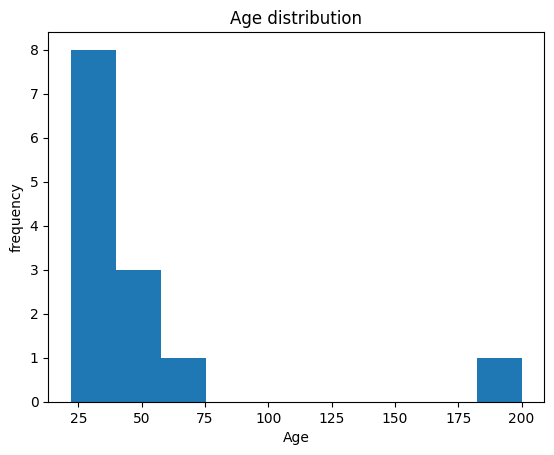

In [427]:
# YOUR CODE HERE
# Hint: plt.hist() বা df['Age'].plot(kind='hist')
# plt.title(), plt.xlabel(), plt.ylabel() দিতে ভুলো না
plt.hist(df['Age'],bins=10)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("frequency")
plt.show()

### 🟡 MEDIUM &nbsp;&nbsp; Question 7
**Salary vs Experience** scatter plot করো এবং দেখো কোনো pattern আছে কিনা।

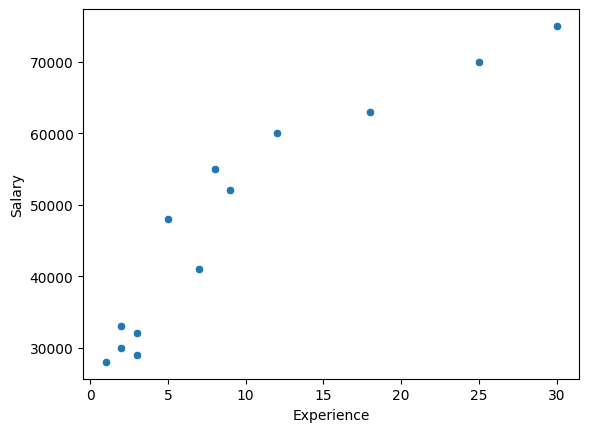

In [428]:
# YOUR CODE HERE
# Hint: sns.scatterplot(data=df, x='Experience', y='Salary')
sns.scatterplot(data=df,x='Experience',y='Salary')
plt.show()

### 🔴 HARD &nbsp;&nbsp; Question 8
Numerical columns এর correlation বের করো এবং **heatmap** দিয়ে visualize করো। `annot=True` দাও।

> চিন্তা করো: Age এবং Experience এর মধ্যে কি strong correlation আছে? কেন?

<Axes: >

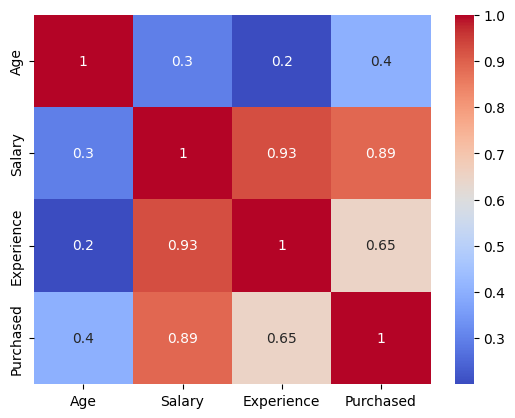

In [429]:
# YOUR CODE HERE
# Hint: df.corr() → sns.heatmap(..., annot=True, cmap='coolwarm')
select_columns=df.select_dtypes(include=('int64','float64'))
corelation=select_columns.corr()
sns.heatmap(corelation,annot=True,cmap='coolwarm')

age and experience are not strong corelation. Although age is increase but exprerience is not increase with this age. on the otherhand experience and salary are more stri=ong correlation.

---
# 📌 Section 2: Train-Test Split & Missing Value Handling
**Module 03**

### 🟢 EASY &nbsp;&nbsp; Question 9
প্রতিটি column এ **কতটি missing value** আছে তা বের করো।

In [430]:
# YOUR CODE HERE
# Hint: .isnull().sum()
df.isnull().sum()

,0
Age,2
Salary,2
City,2
Education,0
Experience,0
Purchased,0


**Expected:** Age=2, Salary=2, City=2

### 🟢 EASY &nbsp;&nbsp; Question 10
**Age** এর missing values **mean** দিয়ে এবং **City** এর missing values **mode** দিয়ে fill করো।

In [431]:
df_clean = df.copy()
df_clean['Age']=df_clean['Age'].fillna(df_clean['Age'].mean())
df_clean['City']=df_clean['City'].fillna(df_clean['City'].mode()[0])


### 🟡 MEDIUM &nbsp;&nbsp; Question 11
**Salary** এর missing values **median** দিয়ে fill করো। Fill করার আগে ও পরে missing count দেখাও।

In [432]:
# YOUR CODE HERE
missing_count=df_clean['Salary'].isnull().sum()
print(f"befor missing count : {missing_count}")
df_clean['Salary']=df_clean['Salary'].fillna(df_clean['Salary'].median())
print(f"after missing count : {df_clean['Salary'].isnull().sum()}")


befor missing count : 2
after missing count : 0


### 🟡 MEDIUM &nbsp;&nbsp; Question 12
**Train-Test Split** করো — 80% training, 20% testing। `random_state=42`।

> Feature (X): Age, Salary, Experience | Target (y): Purchased

In [433]:
X = df_clean[['Age', 'Salary', 'Experience']]
y = df_clean['Purchased']

# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Print sizes
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 12, Test size: 3


**Expected:** Train size: 12, Test size: 3

### 🔴 HARD &nbsp;&nbsp; Question 13
Train-Test Split করার পরে `y_train` এবং `y_test` এ **class distribution** (0 এবং 1 এর ratio) দেখাও। Distribution কি balanced?

> Hint: `.value_counts(normalize=True)` দিয়ে percentage বের করো।

In [434]:
# YOUR CODE HERE
# y_train distribution

# y_test distribution

# তোমার observation লেখো (comment এ):
# "Train এ class 0 আছে X%, class 1 আছে Y%..."

print(y_train.value_counts(normalize=True)*100,"\n")

print(y_test.value_counts(normalize=True)*100)

Purchased
1    58.333333
0    41.666667
Name: proportion, dtype: float64 

Purchased
1    66.666667
0    33.333333
Name: proportion, dtype: float64


---
# 📌 Section 3: Outlier Detection and Handling
**Module 05 & 06**

### 🟢 EASY &nbsp;&nbsp; Question 14
**Age** column এর **boxplot** তৈরি করো।

<Axes: ylabel='Age'>

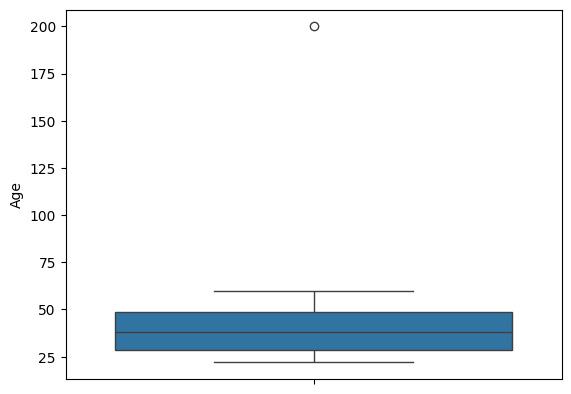

In [435]:
# YOUR CODE HERE
# Hint: sns.boxplot(y=df_clean['Age'])
sns.boxplot(y=df_clean['Age'])

**Note:** Age=200 clearly একটি outlier।

### 🟡 MEDIUM &nbsp;&nbsp; Question 15
**IQR Method** দিয়ে **Age** column এর outlier detect করো এবং outlier rows দেখাও।

> IQR = Q3 - Q1 | Lower = Q1 - 1.5×IQR | Upper = Q3 + 1.5×IQR

In [436]:
Q1 = df_clean['Age'].quantile(0.25)
Q3 = df_clean['Age'].quantile(0.75)

# YOUR CODE HERE
# IQR calculate করো
IQR=Q3-Q1
# Lower এবং Upper bound
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
# Outlier rows 1দেখাও
outliers = df_clean[(df_clean['Age'] < lower) | (df_clean['Age'] > upper)]

outliers['Age']


,Age
11,200.0


In [437]:
df_clean

,Age,Salary,City,Education,Experience,Purchased
0,25.000000,30000.0,Dhaka,HSC,2,0
1,32.000000,55000.0,Chittagong,Graduate,8,1
2,48.846154,48000.0,Dhaka,Graduate,5,1
3,45.000000,48000.0,Sylhet,Masters,15,1
4,28.000000,32000.0,Dhaka,HSC,3,0
5,60.000000,75000.0,Dhaka,PhD,30,1
6,22.000000,28000.0,Rajshahi,HSC,1,0
7,38.000000,60000.0,Chittagong,Graduate,12,1
8,48.846154,41000.0,Dhaka,Masters,7,0
9,55.000000,70000.0,Sylhet,PhD,25,1


**Expected:** Age=200 row outlier হিসেবে detected হবে।

### 🟡 MEDIUM &nbsp;&nbsp; Question 16
**Z-Score Method** দিয়ে outlier detect করো। |Z| > 3 হলে outlier।

> Z = (x - mean) / std

In [438]:
# YOUR CODE HERE
mean_age = df_clean['Age'].mean()
std_age  = df_clean['Age'].std()

z_score=(df_clean['Age']-mean_age)/std_age
outlier=df_clean[z_score.abs() > 3]
print(len(outlier))
display(outlier)

1


,Age,Salary,City,Education,Experience,Purchased
11,200.0,52000.0,Dhaka,Graduate,9,1


### 🟡 MEDIUM &nbsp;&nbsp; Question 17
IQR method এ detected outlier rows **remove** করো। নতুন shape দেখাও।

In [439]:
# YOUR CODE HERE
# Hint: bound এর মধ্যে আছে এমন rows রাখো
no_outlier=df_clean[(df_clean['Age'] >= lower) & (df_clean['Age'] <= upper)]
no_outlier.shape

(14, 6)

**Expected:** Shape (14, 6) — 1 row removed.

### 🔴 HARD &nbsp;&nbsp; Question 18
Outlier remove করার বদলে **cap** করো (Winsorization)। তারপর before vs after boxplot side-by-side দেখাও।

> Cap মানে: outlier value কে bound এর value দিয়ে replace করা।

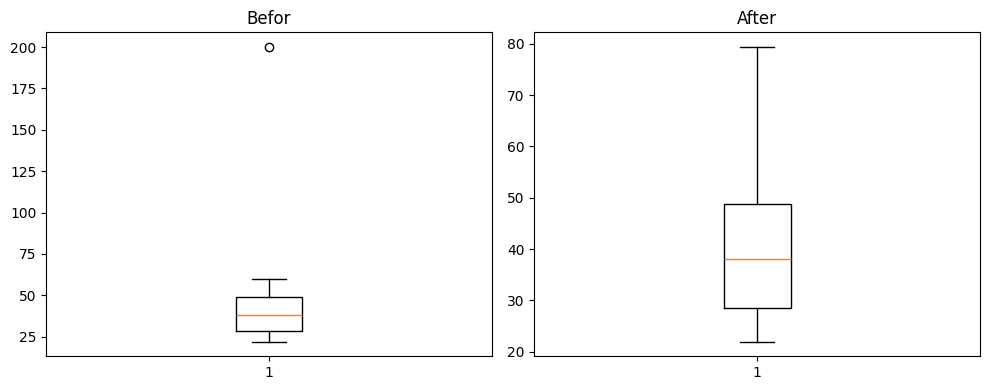

In [440]:
df_capped = df_clean.copy()

# YOUR CODE HERE
# Step 1: Cap করো
# Hint: df_capped['Age'] = df_capped['Age'].clip(lower=lower_bound, upper=upper_bound)
df_capped['Age']=df_capped['Age'].clip(lower=lower,upper=upper)
# Step 2: Before vs After boxplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df_clean['Age'])
axes[0].set_title('Befor')
axes[1].boxplot(df_capped['Age'])
axes[1].set_title('After')
plt.tight_layout()
plt.show()

---
# 📌 Section 4: Encoding
**Module 07**

### 🟢 EASY &nbsp;&nbsp; Question 19
**Label Encoding** দিয়ে **Education** column কে numerical করো।

In [450]:
df_encoded = df_clean.copy()
le = LabelEncoder()
# YOUR CODE HERE
# df_encoded['Education_Encoded'] = le.fit_transform(...)
df_encoded['Education_Encoded'] = le.fit_transform(df_encoded['Education'])
df_encoded

,Age,Salary,City,Education,Experience,Purchased,Education_Encoded
0,25.000000,30000.0,Dhaka,HSC,2,0,1
1,32.000000,55000.0,Chittagong,Graduate,8,1,0
2,48.846154,48000.0,Dhaka,Graduate,5,1,0
3,45.000000,48000.0,Sylhet,Masters,15,1,2
4,28.000000,32000.0,Dhaka,HSC,3,0,1
5,60.000000,75000.0,Dhaka,PhD,30,1,3
6,22.000000,28000.0,Rajshahi,HSC,1,0,1
7,38.000000,60000.0,Chittagong,Graduate,12,1,0
8,48.846154,41000.0,Dhaka,Masters,7,0,2
9,55.000000,70000.0,Sylhet,PhD,25,1,3


### 🟢 EASY &nbsp;&nbsp; Question 20
**One-Hot Encoding** দিয়ে **City** column কে encode করো। `pd.get_dummies()` ব্যবহার করো।

In [451]:
# YOUR CODE HERE
# Hint: pd.get_dummies(df_encoded, columns=['City'], drop_first=True)
pd.get_dummies(df_encoded, columns=['City'], drop_first=True)

,Age,Salary,Education,Experience,Purchased,Education_Encoded,City_Dhaka,City_Rajshahi,City_Sylhet
0,25.000000,30000.0,HSC,2,0,1,True,False,False
1,32.000000,55000.0,Graduate,8,1,0,False,False,False
2,48.846154,48000.0,Graduate,5,1,0,True,False,False
3,45.000000,48000.0,Masters,15,1,2,False,False,True
4,28.000000,32000.0,HSC,3,0,1,True,False,False
5,60.000000,75000.0,PhD,30,1,3,True,False,False
6,22.000000,28000.0,HSC,1,0,1,False,True,False
7,38.000000,60000.0,Graduate,12,1,0,False,False,False
8,48.846154,41000.0,Masters,7,0,2,True,False,False
9,55.000000,70000.0,PhD,25,1,3,False,False,True


**Note:** `drop_first=True` দিলে dummy variable trap avoid হয়।

### 🟡 MEDIUM &nbsp;&nbsp; Question 21
Label Encoded **Education** এর mapping dictionary দেখাও — কোন label কোন number পেয়েছে।

In [452]:
# YOUR CODE HERE
# Hint: dict(zip(le.classes_, le.transform(le.classes_)))
dict(zip(le.classes_,le.transform(le.classes_)))

{'Graduate': np.int64(0),
 'HSC': np.int64(1),
 'Masters': np.int64(2),
 'PhD': np.int64(3)}

**Expected:** `{'Graduate': 0, 'HSC': 1, 'Masters': 2, 'PhD': 3}`

### 🔴 HARD &nbsp;&nbsp; Question 22
Label Encoding এবং One-Hot Encoding এর মধ্যে পার্থক্য কী? **Education** column এ কোনটা ব্যবহার করা সঠিক এবং কেন?

> দুটো method ই apply করো এবং output compare করো। তারপর নিচে comment এ তোমার reasoning লেখো।

In [444]:
# Method 1: Label Encoding

# Method 2: One-Hot Encoding


# তোমার answer (comment এ লেখো):
# Education column এ _____ ভালো কারণ ___________


---
# 📌 Section 5: Scaling
**Module 08**

### 🟢 EASY &nbsp;&nbsp; Question 23
**MinMaxScaler** দিয়ে **Experience** column কে 0–1 এর মধ্যে scale করো।

> Formula: x_scaled = (x - min) / (max - min)

In [445]:
mm_scaler = MinMaxScaler()
df_scaled  = df_clean.copy()

# YOUR CODE HERE


**Expected:** Experience values এখন 0.0 থেকে 1.0 এর মধ্যে।

### 🟡 MEDIUM &nbsp;&nbsp; Question 24
**StandardScaler** দিয়ে **Age** এবং **Salary** scale করো। Scaling এর পর mean ≈ 0 এবং std ≈ 1 verify করো।

In [446]:
std_scaler = StandardScaler()

# YOUR CODE HERE
# Scale করো

# Verify: mean এবং std print করো


**Expected:** Mean ≈ 0.0, Std ≈ 1.0

### 🟡 MEDIUM &nbsp;&nbsp; Question 25
**Age** column এর scaling এর আগে ও পরে distribution **side-by-side histogram** দিয়ে compare করো।

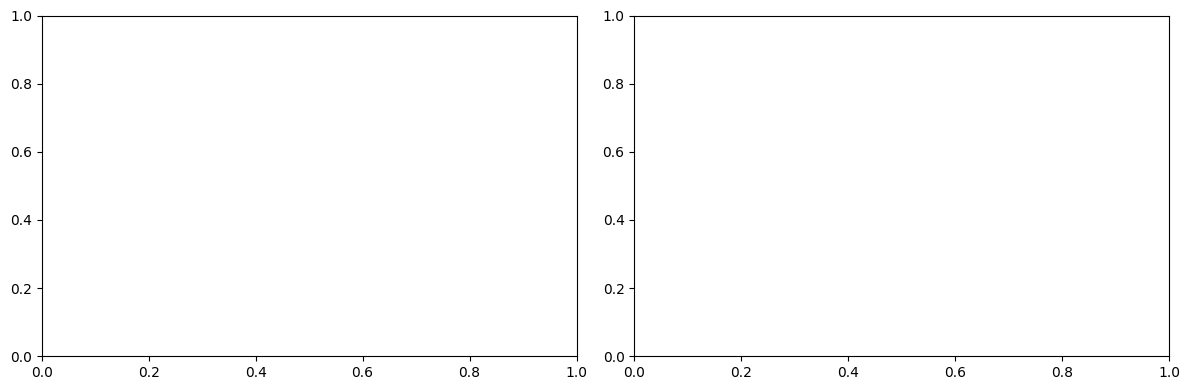

In [447]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# YOUR CODE HERE
# axes[0] → Before scaling
# axes[1] → After scaling

plt.tight_layout()
plt.show()

### 🔴 HARD &nbsp;&nbsp; Question 26
StandardScaler এবং MinMaxScaler এর মধ্যে পার্থক্য কী? **Salary** column এ দুটোই apply করো এবং output compare করো।

> কোন situation এ কোনটা use করবে? Comment এ reasoning লেখো।

In [448]:
salary = df_clean[['Salary']]

# StandardScaler apply করো


# MinMaxScaler apply করো


# দুটো result compare করো (print অথবা plot)





---
# 🌟 Bonus: Full Pipeline
**Combine everything — end-to-end preprocessing**

### 🔴 HARD &nbsp;&nbsp; Question 27 (Bonus)
নিচের সব steps follow করে একটি **complete preprocessing pipeline** তৈরি করো:

1. Missing values handle করো
2. Outliers cap করো (IQR method)
3. City → One-Hot Encode
4. Education → Label Encode
5. Age, Salary, Experience → StandardScale
6. 80/20 Train-Test Split
7. Final train/test shape print করো

In [449]:
df_pipeline = df.copy()

# Step 1: Missing values


# Step 2: Outlier capping


# Step 3: One-Hot Encoding


# Step 4: Label Encoding


# Step 5: Standard Scaling


# Step 6: Train-Test Split


# Step 7: Print shapes
print('Pipeline complete!')


Pipeline complete!
